In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from starforge.blackholes.parameters_recover.parameters_recovery import ParametersRecoveryRemote
from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)
from starforge.blackholes.accretionrate.blackholesaccretionrate import ParameterAccretionRate
from starforge.blackholes.parameters_recover.utils import add_noise_to_data, gaussian_sum_from_p
from starforge.blackholes.parameters_recover.utils import make_bounds_for_gaussians
from starforge.blackholes.parameters_recover.schemes import GridParameters
import ray

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-25 08:51:11,757	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8266 


In [4]:
# ============================================================
# SETTINGS
# ============================================================

N_REALIZATIONS = 10

noise_levels = [0.01, 0.03, 0.05, 0.10]

MODEL_PARAM_COUNT = 7

In [5]:
mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [6]:
# ============================================================
# TRUE MODEL
# ============================================================

true_parameters = [
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01,
    2,
    3e-1,
    5,
    0.1,
    1,
    0.1,
    0.1,
]

In [7]:
parameters_observational = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])


initial_condition = gaussian_sum_from_p(
    parameters_observational,
    ln_mbh_grid,
    n_gauss=3
)

In [8]:
# ============================================================
# FORWARD MODEL
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

true_accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

outputs_true = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        true_accretion_params
    )
)

true_final_data = outputs_true.n_final.copy()

In [9]:
initial_parameters = np.abs(np.random.randn(16))

# bounds = tuple([(0.001, 15) for _ in range(16)])  # 9 for gaussians, 7 for physical params

# ---- Define bounds for optimization ----

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)


bounds.extend([  # For eta, tau_par, alpha_par
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),   # tau_par Gyr
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),    # t_q Gyr
    (0.01, 0.5),   # b_1
    (0.01, 0.5)    # b_2
])

In [10]:
# ============================================================
# SINGLE REALIZATION
# ============================================================

def run_single_realization(noise_level, seed):

    # --------------------------------------------------------
    # noisy synthetic observations
    # --------------------------------------------------------

    target_data = add_noise_to_data(
        data=true_final_data,
        mu=0.0,
        sigma=noise_level,
        rho=0.5,
        alpha=0.5,
        seed=seed,
        noise_type="mixed"
    )

    # --------------------------------------------------------
    # inversion
    # --------------------------------------------------------

    result = ray.get(
        objective_function.optimizer.remote(
            bounds=bounds,
            target_data=target_data,
            weight_p=0.1,
            weight_theta=0.1,
            use_de=True,
            fast_mode=False,
        )
    )

    best_params = result.x   


    model_parameters = best_params[-MODEL_PARAM_COUNT:] 
    # Build physical model parameters
    accretion_params_recovered = ParameterAccretionRate(
        mbh_par=model_parameters[0] * 1e11,
        tau_par=model_parameters[1] * 1e9,
        alpha_par=model_parameters[2],

        eta=model_parameters[3],
        t_q=model_parameters[4] * 1e9,
        b_1=model_parameters[5],
        b_2=model_parameters[6]
    )

    

    # --------------------------------------------------------
    # recovered initial condition
    # --------------------------------------------------------

    gaussian_parameters = best_params[:-MODEL_PARAM_COUNT]

    recovered_initial = gaussian_sum_from_p(
        gaussian_parameters,
        ln_mbh_grid,
        n_gauss=3
    )


    outputs_recovery = ray.get(
        objective_function.directly_problem.remote(
            recovered_initial,
            accretion_params_recovered
        )
    )

    # -------------------------------------------------

    recovered_output = outputs_recovery.n_final

    # --------------------------------------------------------
    # reconstruction metrics
    # --------------------------------------------------------

    metrics = {
        "noise_level": noise_level,
        "seed": seed,

        "nrmse_initial": nrmse_percent(
            initial_condition,
            recovered_initial,
            denom="mean"
        ),

        "smape_initial": smape_percent(
            initial_condition,
            recovered_initial
        ),

        "mape_initial": stabilized_mape_percent(
            initial_condition,
            recovered_initial
        ),

        "nrmse_final": nrmse_percent(
            target_data,
            recovered_output,
            denom="mean"
        ),

        "smape_final": smape_percent(
            target_data,
            recovered_output
        ),

        "mape_final": stabilized_mape_percent(
            target_data,
            recovered_output
        ),
    }

    return metrics

In [11]:
# ============================================================
# MONTE CARLO LOOP
# ============================================================

all_results = []
path_tmp = "./results/monte_carlo_parameter_recovery/"

os.makedirs(path_tmp, exist_ok=True)

for noise_level in noise_levels:

    print(f"\nNoise level = {noise_level:.2%}")

    for seed in range(N_REALIZATIONS):

        file_name = f"{path_tmp}noise_{noise_level:.2f}_seed_{seed}.csv"

        # ====================================================
        # LOAD PREVIOUS RESULT
        # ====================================================

        if os.path.exists(file_name):

            print(f"  realization {seed+1}/{N_REALIZATIONS} already exists. Loading.")

            df_saved = pd.read_csv(file_name)

            all_results.append(df_saved.iloc[0].to_dict())

            continue

        # ====================================================
        # RUN NEW REALIZATION
        # ====================================================

        print(f"  realization {seed+1}/{N_REALIZATIONS}")

        metrics = run_single_realization(
            noise_level=noise_level,
            seed=seed
        )

        all_results.append(metrics)

        pd.DataFrame([metrics]).to_csv(
            file_name,
            index=False
        )

# ============================================================
# FINAL DATAFRAME
# ============================================================

df = pd.DataFrame(all_results)


Noise level = 1.00%
  realization 1/10
(ParametersRecovery pid=2566175) Starting optimization ...
(ParametersRecovery pid=2566175) Objective value: 1.679118e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.523248e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.456872e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.391197e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.293452e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=2566175) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=2566175)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=2566175) Objective value: 1.255420e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.230701e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.200953e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.198750e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.189060e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.184077e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.128291e+02 | Context: Detection occurred in local search
(ParametersRecovery pid=2566175) Objective value: 1.122827e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 1.104331e+02 | Context: Detection occurred in local searc

(ParametersRecovery pid=2566175) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:230: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=2566175)   normalization_model = np.log10(params_array[-n:] + epsilon)
(ParametersRecovery pid=2566175) /home/eduardo/Projects/starforge2/src/starforge/blackholes/discreteblackholemf/blackholesmassfunction.py:86: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=2566175)   x = log10_m_grid - np.log10(self.accretionrate.params.mbh_par)


(ParametersRecovery pid=2566175) Objective value: 7.467865e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 6.912615e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 6.208897e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 6.184311e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 5.984454e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 5.983696e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 3.746011e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 3.736349e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=2566175) Objective value: 3.735461e+01 | Context: Minimum detected in annealing 

In [12]:
# ============================================================
# DATAFRAME
# ============================================================

print(df.head())

   noise_level  seed  nrmse_initial  smape_initial  mape_initial  nrmse_final  \
0         0.01     0     227.483179     168.271335  35663.902026    26.237044   
1         0.01     1      17.899294      13.733865     14.430308     8.968403   
2         0.01     2      29.962656      49.238097    597.786026     8.307029   
3         0.01     3      36.337275      49.948266     35.163027    15.480527   
4         0.01     4      91.150670      98.752773  57758.303756     7.673373   

   smape_final  mape_final  
0    15.781351    9.486330  
1     2.321736    1.916692  
2     6.192778    3.857954  
3     7.992634    5.304931  
4    12.488965    8.160312  


In [13]:
df.to_csv("./results/monte_carlo_parameter_recover_results.csv", index=False)

In [14]:
df = pd.read_csv("./results/monte_carlo_parameter_recover_results.csv")

In [15]:
summary = (
    df.groupby("noise_level")
    .agg(
        {
            "nrmse_initial": ["mean", "std"],
            "smape_initial": ["mean", "std"],
            "mape_initial": ["mean", "std"],
            "nrmse_final": ["mean", "std"],
            "smape_final": ["mean", "std"],
            "mape_final": ["mean", "std"],
        }
    )
)

print(summary)

            nrmse_initial            smape_initial             mape_initial  \
                     mean        std          mean        std          mean   
noise_level                                                                   
0.01            67.347339  62.841996     70.775505  44.308456  59664.928872   
0.03            52.861881  30.936657     72.197293  22.781711  44808.605407   
0.05            56.642690  22.373681     75.950650  26.186732     51.900487   
0.10            78.389853  34.004323     83.063867  26.826718   9513.115119   

                           nrmse_final            smape_final            \
                       std        mean        std        mean       std   
noise_level                                                               
0.01         156859.899495   18.119427  13.537812    8.541144  4.255937   
0.03         141465.272271   19.977435  16.507515   10.560318  5.838614   
0.05             18.770041   14.676025   7.999818    8.206836  3.325178

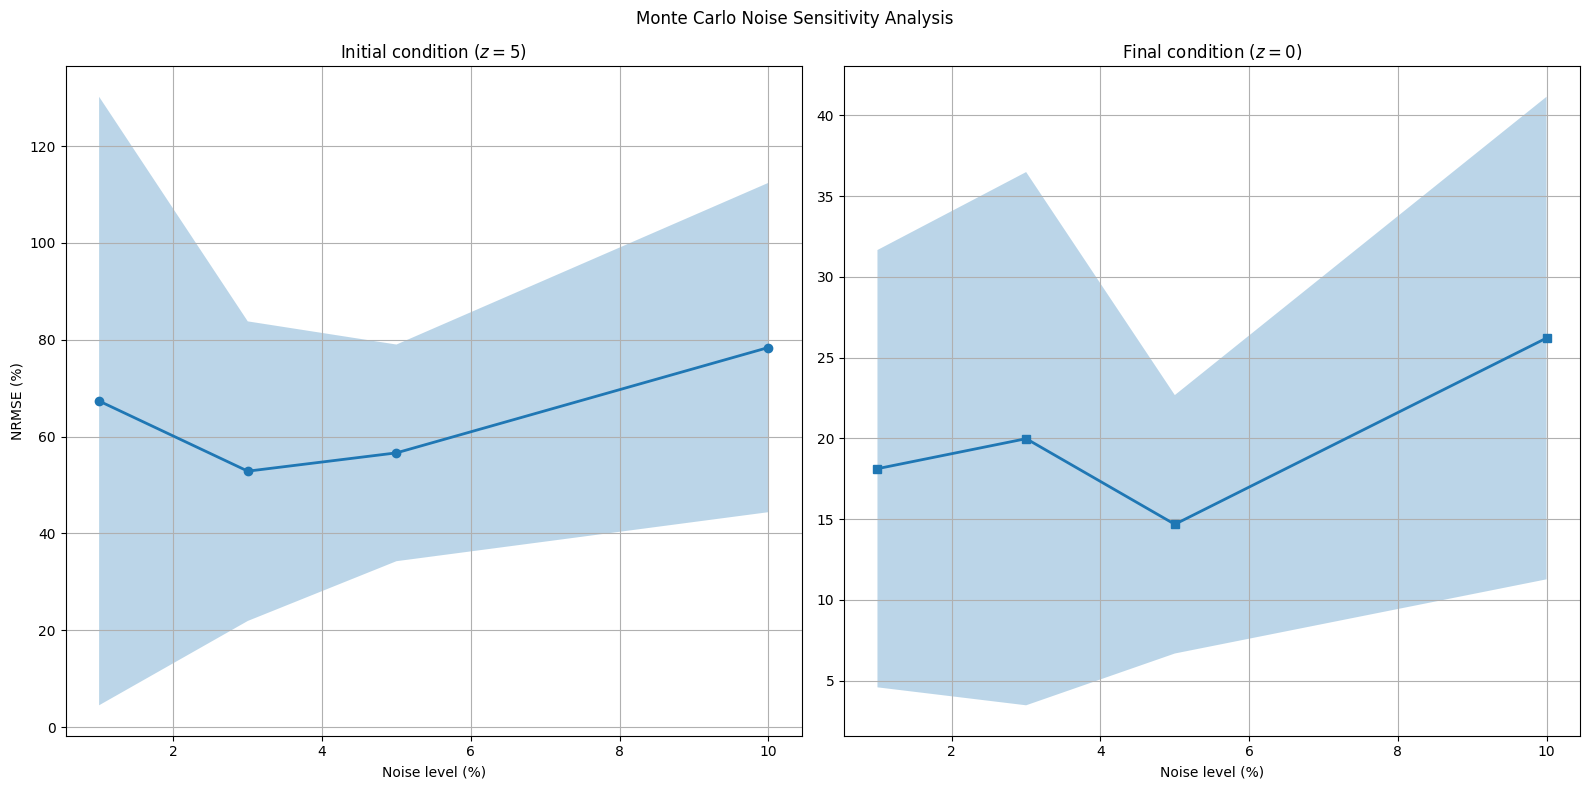

In [18]:

# ============================================================
# PLOT
# ============================================================

noise_percent = 100 * np.array(noise_levels)

# ============================================================
# INITIAL CONDITION
# ============================================================

mean_nrmse_initial = (
    df.groupby("noise_level")["nrmse_initial"]
    .mean()
    .values
)

std_nrmse_initial = (
    df.groupby("noise_level")["nrmse_initial"]
    .std()
    .values
)

# ============================================================
# FINAL CONDITION
# ============================================================

mean_nrmse_final = (
    df.groupby("noise_level")["nrmse_final"]
    .mean()
    .values
)

std_nrmse_final = (
    df.groupby("noise_level")["nrmse_final"]
    .std()
    .values
)

# ============================================================
# FIGURE WITH TWO PANELS
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    sharex=True
)

# ============================================================
# LEFT PANEL — INITIAL CONDITION
# ============================================================

axes[0].plot(
    noise_percent,
    mean_nrmse_initial,
    marker="o",
    linewidth=2
)

axes[0].fill_between(
    noise_percent,
    mean_nrmse_initial - std_nrmse_initial,
    mean_nrmse_initial + std_nrmse_initial,
    alpha=0.3
)

axes[0].set_title("Initial condition ($z=5$)")
axes[0].set_xlabel("Noise level (%)")
axes[0].set_ylabel("NRMSE (%)")
axes[0].grid(True)

# ============================================================
# RIGHT PANEL — FINAL CONDITION
# ============================================================

axes[1].plot(
    noise_percent,
    mean_nrmse_final,
    marker="s",
    linewidth=2
)

axes[1].fill_between(
    noise_percent,
    mean_nrmse_final - std_nrmse_final,
    mean_nrmse_final + std_nrmse_final,
    alpha=0.3
)

axes[1].set_title("Final condition ($z=0$)")
axes[1].set_xlabel("Noise level (%)")
axes[1].grid(True)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle("Monte Carlo Noise Sensitivity Analysis")

plt.tight_layout()

plt.savefig(
    "./images/monte_carlo_noise.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# \caption{
# Monte Carlo sensitivity analysis for different observational noise levels. The left panel shows the mean NRMSE and corresponding $\pm1\sigma$ dispersion for the reconstructed initial condition at $z=5$, while the right panel presents the same quantities for the reconstructed present-day distribution at $z=0$. Results were obtained from 10 independent stochastic realizations for each noise level.
# }